# Procesamiento Digital de Imágenes - TP02 (Parte 2): Manejo de Histograma

**Objetivos de la guía:**

* Interpretar la información provista por histogramas de intensidades.
* Analizar las similitudes y diferencias de los histogramas.
* Comprobar los efectos de la ecualización de histogramas.



In [ ]:
# Configuración e Importaciones]
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Función auxiliar para mostrar imagen e histograma lado a lado
def mostrar_img_y_espectro(img, titulo="Imagen"):
    if img is None:
        print(f"Error: Imagen no encontrada para {titulo}")
        return

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Mostrar imagen
    axs[0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axs[0].set_title(titulo)
    axs[0].axis('off')
    # Calcular y mostrar histograma
    histr = cv2.calcHist([img], [0], None, [256], [0, 256])
    axs[1].plot(histr, color='black')
    axs[1].set_title('Histograma de Intensidades')
    axs[1].set_xlim([0, 256])
    axs[1].grid(True)

    plt.show()

print("Entorno configurado. Recuerda subir todas las imágenes al entorno de Colab.")

Entorno configurado. Recuerda subir todas las imágenes al entorno de Colab.


## Ejercicio 1: Manejo de Histograma

Analizaremos la información que brindan los histogramas sobre las imágenes.

* Carga y primer análisis
* Cargue las imágenes patron2.tif y patron.tif (a escala de grises).
* Reflexione acerca de **qué espera obtener** y verifique graficando.


Análisis de patron.tif:


AttributeError: 'numpy.ndarray' object has no attribute 'imshow'

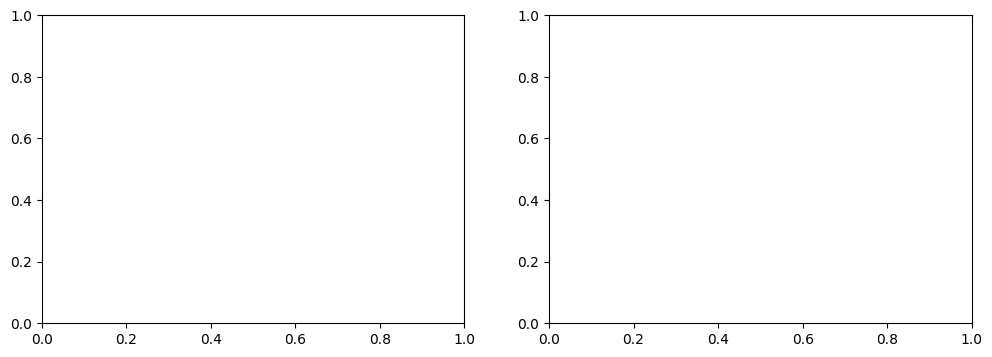

In [6]:
# Histogramas Básicos]

img_patron = cv2.imread('../Imagenes_cursado/patron.tif', cv2.IMREAD_GRAYSCALE)
img_patron2 = cv2.imread('../Imagenes_cursado/patron2.tif', cv2.IMREAD_GRAYSCALE)

# Mostrar y analizar
print("Análisis de patron.tif:")
mostrar_img_y_espectro(img_patron, "Patrón 1")

print("Análisis de patron2.tif:")
mostrar_img_y_espectro(img_patron2, "Patrón 2")



### Correspondencia y Estadística

* Emparejar imágenes (imagenA.tif a E) con sus respectivos histogramas (histo1.tif a 5).
* Luego, extraer propiedades estadísticas.


* Analiza visualmente los archivos histo1 a histo5. Anota aquí tu correspondencia esperada y **justifica**:
* **histo1.tif -> imagen?.tif**
    * ¿Es clara/Oscura?
    * ¿Buen contraste?
    * etc.



In [ ]:
def calcular_estadisticas(img):
    """Calcula media, varianza, asimetría, energía y entropía de un histograma"""
    if img is None: return

    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    hist_norm = hist.ravel() / hist.sum() # Probabilidad de cada nivel de gris
    niveles = np.arange(256)

    # 1. Media
    media = 0 # TODO: Reemplazar con el cálculo real

    # 2. Varianza
    varianza = 0 # TODO: Reemplazar

    # 3. Asimetría (Skewness)
    asimetria = 0 # TODO: Calcular asimetría

    # 4. Energía
    energia = 0 # TODO: Reemplazar

    # 5. Entropía (Cuidado con el logaritmo de 0)
    # entropia = -np.sum(hist_norm[hist_norm > 0] * np.log2(hist_norm[hist_norm > 0]))
    entropia = 0 # TODO: Reemplazar

    print(f"Media: {media:.2f} | Varianza: {varianza:.2f} | Energía: {energia:.4f} | Entropía: {entropia:.4f}")

# Carga una de las imágenes de prueba para calcular sus estadísticas
img_test = cv2.imread('imagenA.tif', cv2.IMREAD_GRAYSCALE)
calcular_estadisticas(img_test)

### Ecualización de histogramas

La **ecualización** busca aplanar el histograma para mejorar el contraste global. Evaluaremos la versión Global y la versión Adaptativa Limitada por Contraste (**CLAHE**).


* Prueba con diferentes imágenes y analiza qué diferencias notas respecto a la teoría.



In [ ]:
def comparar_ecualizaciones(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: No se pudo cargar la imagen: {img_path}")
        return "Carga una imagen válida."

    # 1. Ecualización Global
    img_equ = np.zeros_like(img) # TODO: Reemplazar con la función equalizeHist de OpenCV

    # 2. Ecualización Adaptativa (CLAHE)
    # clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    # img_clahe = clahe.apply(img)
    img_clahe = np.zeros_like(img) # TODO: Reemplazar y analizar parámetros

    # Visualización comparativa
    fig, axs = plt.subplots(3, 2, figsize=(12, 12))

    # Original
    axs[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axs[0, 0].set_title("Original")
    axs[0, 0].axis('off')

    axs[0, 1].plot(cv2.calcHist([img], [0], None, [256], [0, 256]), color='black')
    axs[0, 1].set_title('Histograma Original')
    axs[0, 1].set_xlim([0, 256])
    axs[0, 1].grid(True)

    # Global
    axs[1, 0].imshow(img_equ, cmap='gray', vmin=0, vmax=255)
    axs[1, 0].set_title("Ecualización Global")
    axs[1, 0].axis('off')

    axs[1, 1].plot(cv2.calcHist([img_equ], [0], None, [256], [0, 256]), color='black')
    axs[1, 1].set_title('Histograma Global')
    axs[1, 1].set_xlim([0, 256])
    axs[1, 1].grid(True)

    # CLAHE
    axs[2, 0].imshow(img_clahe, cmap='gray', vmin=0, vmax=255)
    axs[2, 0].set_title("Ecualización CLAHE")
    axs[2, 0].axis('off')

    axs[2, 1].plot(cv2.calcHist([img_clahe], [0], None, [256], [0, 256]), color='black')
    axs[2, 1].set_title('Histograma CLAHE')
    axs[2, 1].set_xlim([0, 256])
    axs[2, 1].grid(True)

    plt.tight_layout()
    plt.show()

# TODO: Prueba con diferentes imágenes y analiza qué diferencias notas respecto a la teoría
comparar_ecualizaciones('imagenA.tif')

## Trabajos de Aplicación



### Aplicación 1: Revelado de detalles ocultos

En **cuadros.tif** hay cuadros negros sobre un fondo casi uniforme. Utilice ecualización local/adaptativa y compare con la global.

In [ ]:
# TODO: Cargar 'cuadros.tif'
img_cuadros = cv2.imread('cuadros.tif', cv2.IMREAD_GRAYSCALE)

# TODO: Aplicar ecualización global
# equ_global = ...

# TODO: Aplicar ecualización local (CLAHE).
# AYUDA DE LA GUÍA: "El tamaño de ventana y su localización es clave para realizar la ecualización local."
# Juega con el parámetro `tileGridSize` de CLAHE.
# clahe_local = ...

# Mostrar y comparar los resultados obtenidos.

### Aplicación 2: Búsqueda por Correlación de Histogramas

Crear un algoritmo que informe el contenido de la imagen (Bandera, Caricatura, Personaje o Paisaje) utilizando los archivos en **Busqueda_histograma.zip**.

In [ ]:
# NOTA: Debes descomprimir 'Busqueda_histograma.zip' en tu entorno de Colab primero.
# Puedes usar: !unzip Busqueda_histograma.zip en una celda separada.

def clasificar_por_histograma(img_query_path, templates_dict):
    """
    Compara el histograma de img_query_path contra los histogramas de las
    imágenes de referencia en templates_dict.
    """
    img_query = cv2.imread(img_query_path)
    if img_query is None: return "Imagen a consultar no encontrada."

    # TODO 1: Calcular histograma de la imagen de consulta (query)
    # Considera si te conviene calcularlo en escala de grises o a color (3 canales).
    # hist_query = cv2.calcHist(...)
    # cv2.normalize(hist_query, hist_query, 0, 1, cv2.NORM_MINMAX)

    mejor_coincidencia = "Desconocido"
    max_correlacion = -1

    for categoria, path_referencia in templates_dict.items():
        img_ref = cv2.imread(path_referencia)
        if img_ref is None: continue

        # TODO 2: Calcular y normalizar el histograma de la imagen de referencia
        # hist_ref = ...

        # TODO 3: Comparar histogramas usando la métrica de correlación
        # correlacion = cv2.compareHist(hist_query, hist_ref, cv2.HISTCMP_CORREL)
        correlacion = 0 # Reemplazar con el cálculo real

        print(f"Correlación con {categoria}: {correlacion:.4f}")

        if correlacion > max_correlacion:
            max_correlacion = correlacion
            mejor_coincidencia = categoria

    print(f"\n--> RESULTADO: La imagen parece ser un/una {mejor_coincidencia}")

    # Visualizar
    # TODO: mostrar_imagen(img_query, f"Clasificación: {mejor_coincidencia}")

# TODO: Configurar el diccionario con las rutas a tus imágenes patrón
referencias = {
    "Bandera": "ref_bandera.jpg",
    "Caricatura": "ref_caricatura.jpg",
    "Personaje": "ref_personaje.jpg",
    "Paisaje": "ref_paisaje.jpg"
}

# TODO: Probar el algoritmo con diferentes imágenes del set
# clasificar_por_histograma("test_imagen1.jpg", referencias)